# Exploratory Data Analysis (EDA)

This notebook performs a preliminary exploration of the NextBuy master dataset.
We examine customer ordering patterns, reorder behavior, and bestselling products to build intuition before feature engineering and modeling.

**Data:** `master_dataset.csv` — generated by `data_clean.py`, which merges `orders.csv`, `order_products.csv`, `products.csv`, `aisles.csv`, and `departments.csv`.

In [ ]:
# Step 1. Load the Master Dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

df = pd.read_csv("master_dataset.csv")
print(f'Dataset: {len(df):,} rows × {len(df.columns)} columns')
print(f'Unique users: {df["user_id"].nunique():,}')
print(f'Unique orders: {df["order_id"].nunique():,}')
print(f'Unique products: {df["product_id"].nunique():,}')
df.head()

## Step 2. Customer Ordering Patterns

We start by understanding **when** customers place their orders — which days, which hours, and how often. These patterns are key for scheduling promotions and optimizing delivery logistics.

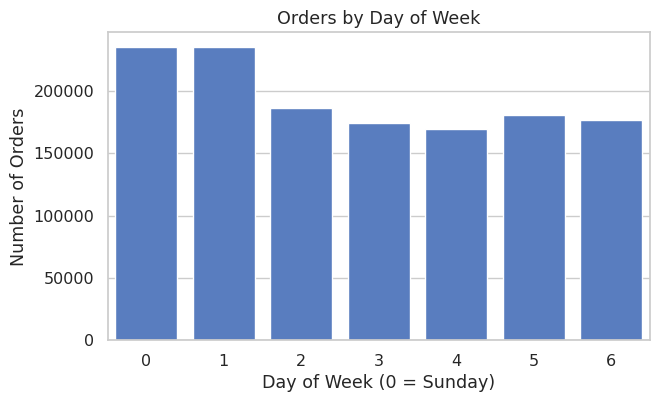

In [ ]:
## Orders by Day of Week
orders_dow = df.groupby("order_dow")["order_id"].nunique()

plt.figure(figsize=(7,4))
sns.barplot(x=orders_dow.index, y=orders_dow.values)
plt.title("Orders by Day of Week")
plt.xlabel("Day of Week (0 = Sunday)")
plt.ylabel("Number of Orders")
plt.show()

**Observation:** Sunday (0) and Monday (1) are the busiest ordering days. Activity gradually decreases toward mid-week, then picks up again on the weekend.

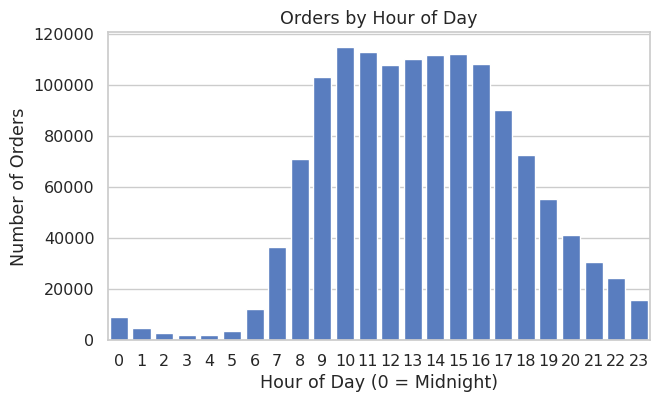

In [ ]:
## Orders by Hour of Day
orders_hour = df.groupby("order_hour_of_day")["order_id"].nunique()

plt.figure(figsize=(7,4))
sns.barplot(x=orders_hour.index, y=orders_hour.values)
plt.title("Orders by Hour of Day")
plt.xlabel("Hour of Day (0 = Midnight)")
plt.ylabel("Number of Orders")
plt.show()

**Observation:** Peak ordering happens between 10am and 4pm, with the absolute peak around 10–11am. Very few orders are placed between midnight and 6am.

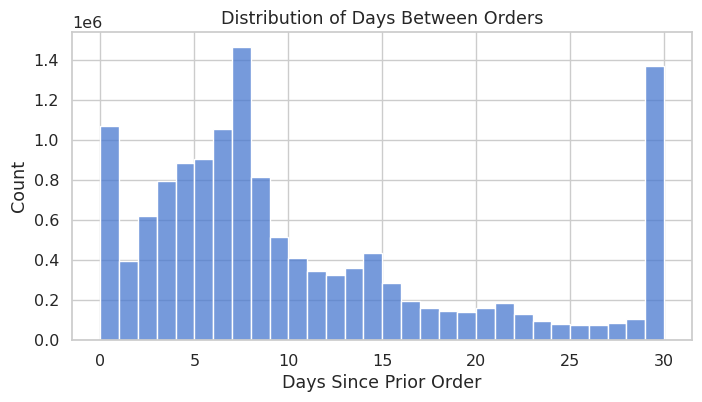

In [ ]:
## Time between Orders
plt.figure(figsize=(8,4))
sns.histplot(df["days_since_prior_order"], bins=30, kde=False)
plt.title("Distribution of Days Between Orders")
plt.xlabel("Days Since Prior Order")
plt.ylabel("Count")
plt.show()

**Observation:** Strong spikes at 7 and 30 days reveal that most customers follow a weekly or monthly shopping routine. This regularity is very useful for predicting when a customer will place their next order.

## Step 3. Reorder Behavior

A large portion of purchases are **reorders** — products the customer has already bought before. Understanding reorder patterns is central to our prediction task.

In [ ]:
## Overall Reorder Rate
overall_rate = df["reordered"].mean()
print(f"Overall Reorder Rate: {overall_rate:.2%}")

Overall Reorder Rate: 58.96%


**Observation:** About ~59% of all products ordered are reorders — customers tend to repurchase items they've bought before, confirming the relevance of a reorder prediction model.

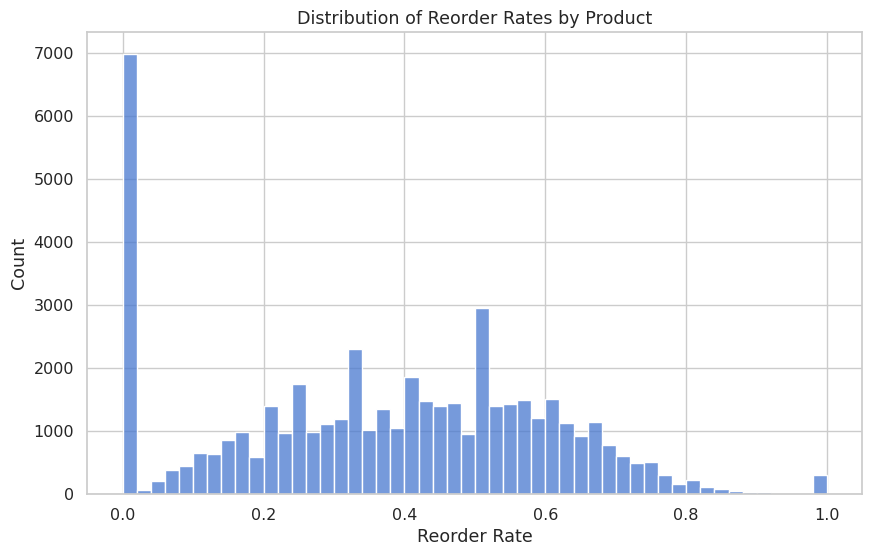

In [ ]:
## Reorder Rate by Product
reorder_rate_product = df.groupby("product_id")["reordered"].mean().sort_values()

plt.figure(figsize=(10,6))
sns.histplot(reorder_rate_product, bins=50, kde=False)
plt.title("Distribution of Reorder Rates by Product")
plt.xlabel("Reorder Rate")
plt.ylabel("Count")
plt.show()

**Observation:** The distribution is bimodal — many products are either rarely reordered (rate near 0) or very frequently reordered (rate near 1). Products with high reorder rates are everyday staples (milk, bread, eggs).

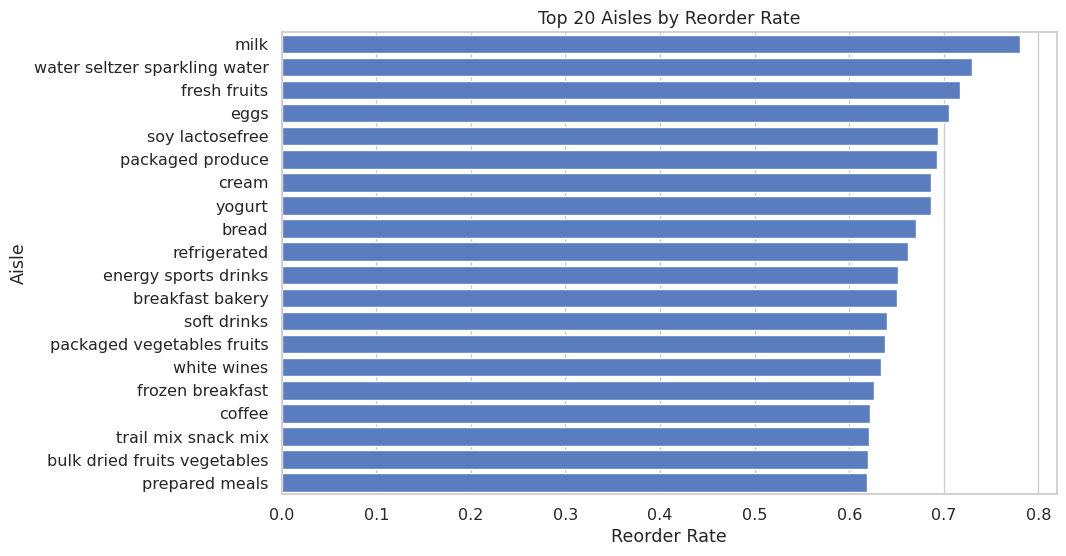

In [ ]:
## Reorder Rate by Aisle
reorder_rate_aisle = df.groupby("aisle")["reordered"].mean().sort_values(ascending=False).head(20)

plt.figure(figsize=(10,6))
sns.barplot(x=reorder_rate_aisle.values, y=reorder_rate_aisle.index)
plt.title("Top 20 Aisles by Reorder Rate")
plt.xlabel("Reorder Rate")
plt.ylabel("Aisle")
plt.show()

**Observation:** Dairy (milk, cream, butter) and staple aisles dominate the top reorder rates. These are everyday necessities that customers replenish regularly.

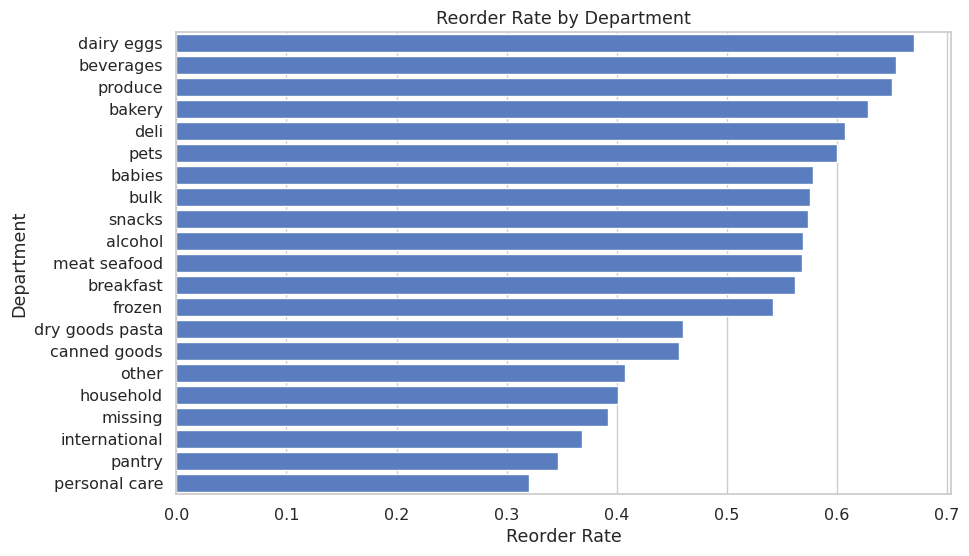

In [ ]:
## Reorder Rate by Department
dept_reorder_rate = df.groupby("department")["reordered"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=dept_reorder_rate.values, y=dept_reorder_rate.index)
plt.title("Reorder Rate by Department")
plt.xlabel("Reorder Rate")
plt.ylabel("Department")
plt.show()

**Observation:** Dairy, produce, and personal care have the highest department-level reorder rates. This aligns with the expectation that consumable, perishable products get repurchased most often.

## Step 4. Bestsellers

Identifying top-selling products, aisles, and departments helps prioritize stock management, marketing, and shelf space allocation.

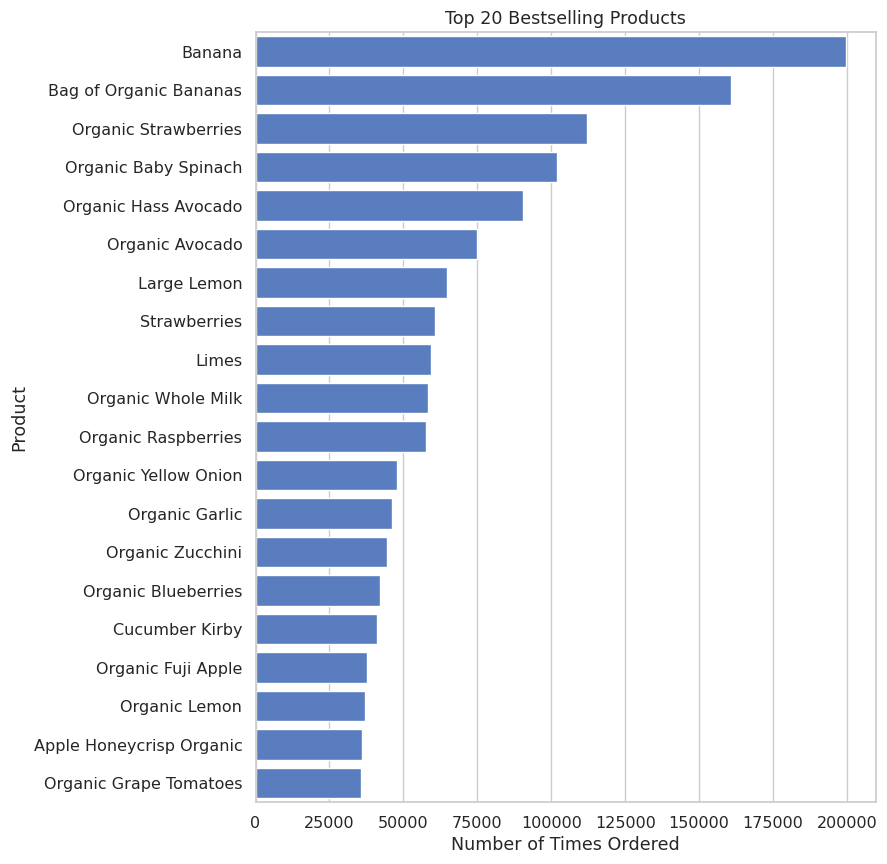

In [ ]:
## Top 20 Products
top_products = df["product_name"].value_counts().head(20)

plt.figure(figsize=(8,10))
sns.barplot(y=top_products.index, x=top_products.values)
plt.title("Top 20 Bestselling Products")
plt.xlabel("Number of Times Ordered")
plt.ylabel("Product")
plt.show()

**Observation:** Bananas dominate by a wide margin. The top 20 is heavily skewed toward fresh produce and organic products, showing strong customer preference for healthy food.

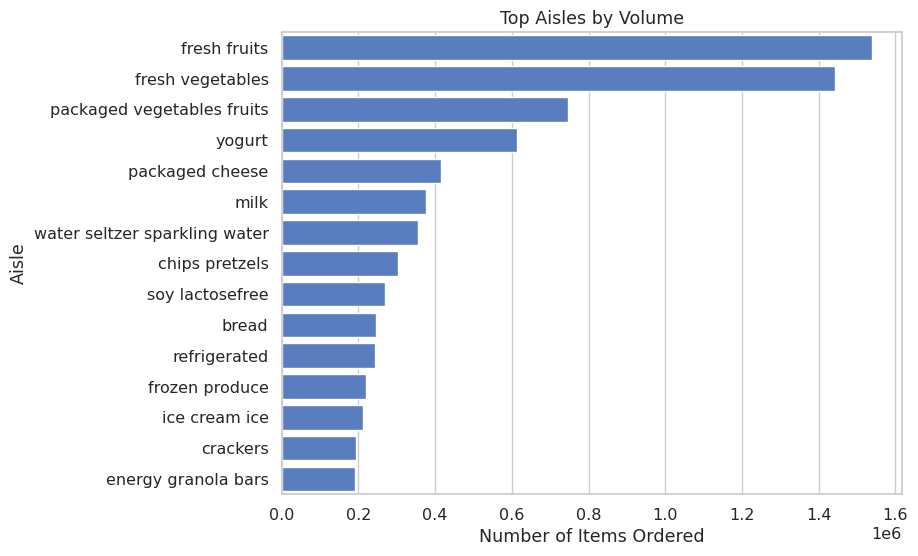

In [ ]:
## Top Aisles
top_aisles = df["aisle"].value_counts().head(15)

plt.figure(figsize=(8,6))
sns.barplot(y=top_aisles.index, x=top_aisles.values)
plt.title("Top Aisles by Volume")
plt.xlabel("Number of Items Ordered")
plt.ylabel("Aisle")
plt.show()

**Observation:** Fresh fruits and fresh vegetables alone represent a massive share of orders. Yogurt, packaged cheese, and milk are also in the top tier.

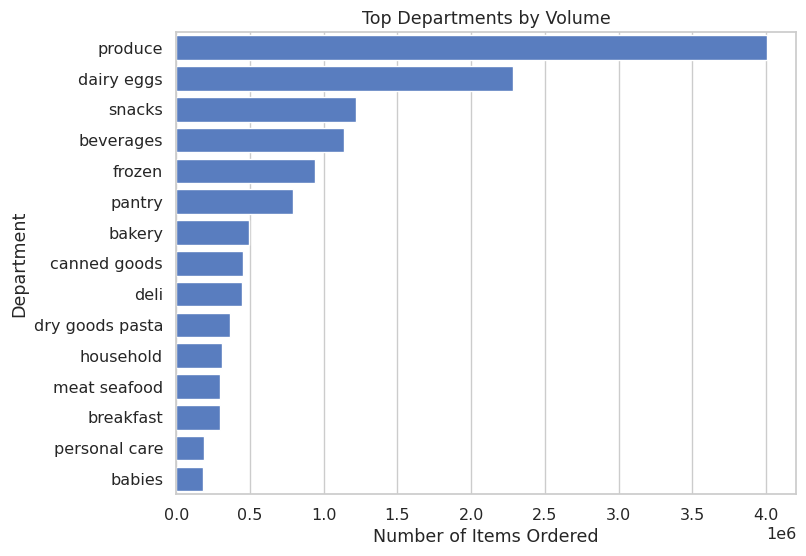

In [ ]:
## Top Departments
top_depts = df["department"].value_counts().head(15)

plt.figure(figsize=(8,6))
sns.barplot(y=top_depts.index, x=top_depts.values)
plt.title("Top Departments by Volume")
plt.xlabel("Number of Items Ordered")
plt.ylabel("Department")
plt.show()

**Observation:** Produce is the #1 department by far. Dairy and snacks follow, confirming the grocery store's heavy reliance on perishable fresh products.

## Step 5. Temporal Heatmap

Combining day of week and hour of day reveals the most precise ordering hotspots.

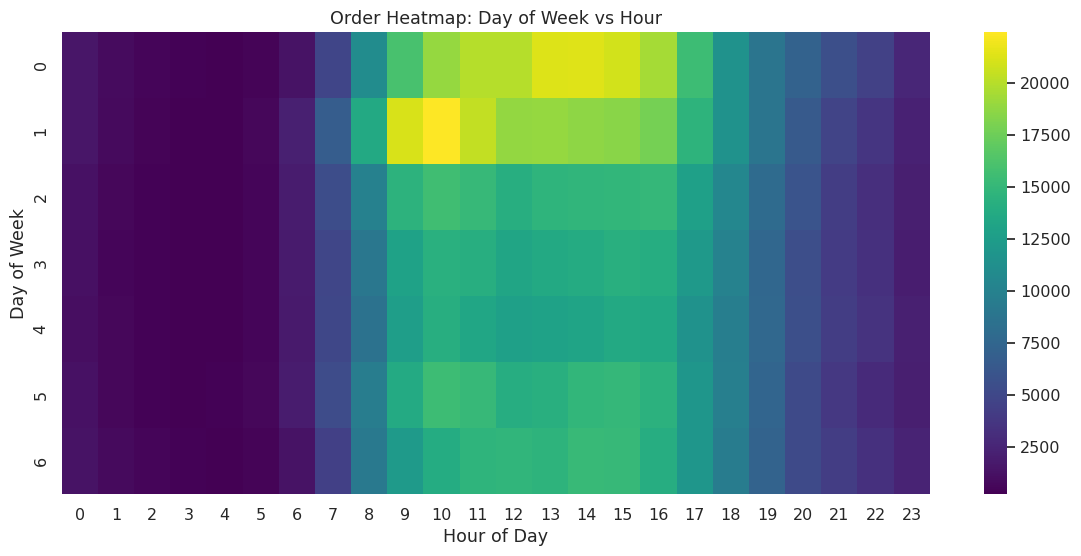

In [ ]:
## Heatmap: Hour x Day Behavior
pivot = df.pivot_table(
    index="order_dow",
    columns="order_hour_of_day",
    values="order_id",
    aggfunc="nunique"
)

plt.figure(figsize=(14,6))
sns.heatmap(pivot, cmap="viridis")
plt.title("Order Heatmap: Day of Week vs Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.show()

**Observation:** The brightest zone is Sunday 10am–3pm, confirming it as the single busiest window. Saturday mornings are also hot. Mid-week evenings and early mornings are consistently quiet across all days.

## Summary

This preliminary EDA reveals several key patterns:
- **Sunday and Monday are peak ordering days**, with 10am–3pm as the busiest window.
- **Weekly and monthly routines** dominate (7-day and 30-day cycles between orders).
- **~59% of items are reorders**, making reorder prediction a high-value task.
- **Produce dominates** across all dimensions (top products, aisles, departments).
- **Dairy and staples** have the highest reorder rates.

These insights inform the feature engineering and predictive modeling done in `notebook.ipynb`.